In [1]:
from pathlib import Path

import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score  # классы несбалансированы
from sklearn.metrics import average_precision_score  # положительный класс -- редкий
from sklearn.metrics import balanced_accuracy_score  # accuracy для дисбаланса
from sklearn.metrics import f1_score

import optuna

In [2]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [3]:
DATA_DIR = Path("/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
submit_path = DATA_DIR / "submit.csv"

for path in [train_path, test_path, submit_path]:
    print(f"{path}:", "OK" if path.exists() else "NOT FOUND")

/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/train.csv: OK
/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/test.csv: OK
/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/submit.csv: OK


In [4]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
submit_df = pd.read_csv(submit_path)

df = train_df.copy()

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("submit shape:", submit_df.shape)

train shape: (247972, 1369)
test shape: (106274, 1368)
submit shape: (106274, 2)


In [5]:
df.head()

,index,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
0,239134,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,1,1,1,1,1,0
1,234708,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,1.0,...,-1.0,-1.0,-1.0,1,1,1,1,0,0,1
2,268300,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,4.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,283077,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,337271,1.0,0.5,0.5,1.0,1.0,1.0,9.0,1.0,1.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247972 entries, 0 to 247971
Columns: 1369 entries, index to feature_1366
dtypes: float64(1361), int64(8)
memory usage: 2.5 GB


In [7]:
df.describe()

,index,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
count,247972.000000,247972.000000,247972.0,247972.0,247972.0,247972.0,247972.000000,247972.000000,247972.000000,247972.000000,...,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000
mean,177081.186364,0.013493,0.5,0.5,1.0,1.0,0.794473,1.864892,1.270490,1.457911,...,-0.143246,-0.145520,-0.149049,0.121848,0.136741,0.096204,0.034742,0.139403,0.190792,0.149783
std,102245.504744,0.115375,0.0,0.0,0.0,0.0,0.715883,1.802944,0.919966,1.622873,...,0.368512,0.364513,0.358193,0.327111,0.343575,0.294872,0.183126,0.346367,0.392926,0.356859
min,2.000000,0.000000,0.5,0.5,1.0,1.0,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,88544.750000,0.000000,0.5,0.5,1.0,1.0,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,177110.500000,0.000000,0.5,0.5,1.0,1.0,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,265596.750000,0.000000,0.5,0.5,1.0,1.0,1.000000,3.000000,2.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,354243.000000,1.000000,0.5,0.5,1.0,1.0,13.000000,30.000000,23.000000,31.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


`test` -- аналогичен, но без `target`.

In [8]:
test_df.shape

(106274, 1368)

In [9]:
feature_cols = [col for col in train_df.columns if col not in ["index", "target"]]

feature_stats = pd.DataFrame(
    {
        "feature_num": [int(col.split("_")[-1]) for col in feature_cols],
        "n_unique": [train_df[col].nunique() for col in feature_cols],
        "n_missing": [train_df[col].isna().sum() for col in feature_cols],
        "top_freq_ratio": [
            train_df[col].value_counts(normalize=True, dropna=False).iloc[0]
            for col in feature_cols
        ],
    }
)

feature_stats = feature_stats.sort_values("feature_num").reset_index(drop=True)

feature_stats.head(5)

,feature_num,n_unique,n_missing,top_freq_ratio
0,0,1,0,1.000000
1,1,1,0,1.000000
2,2,1,0,1.000000
3,3,1,0,1.000000
4,4,13,0,0.532379


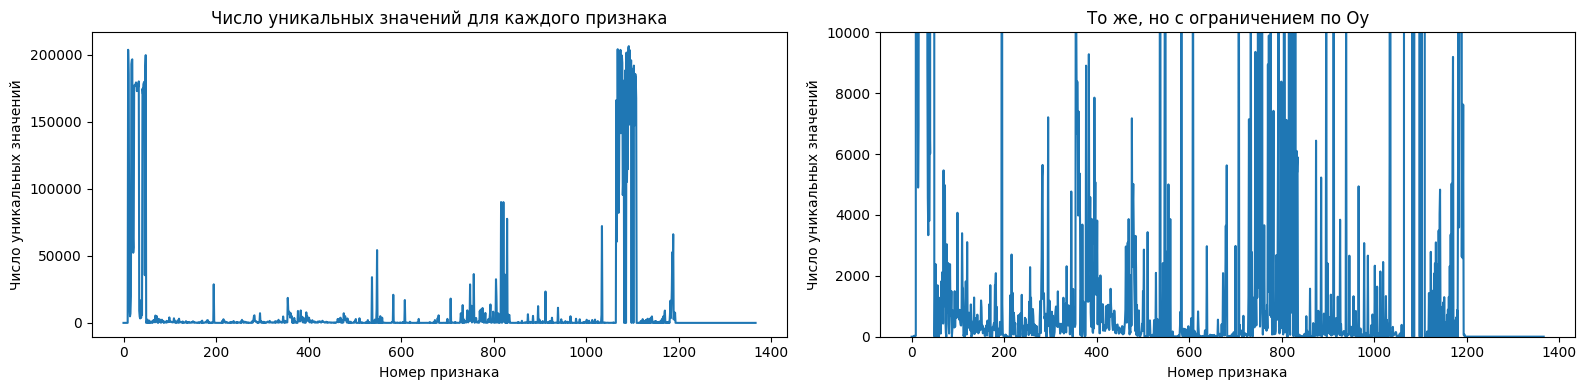

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

ax[0].plot(feature_stats["feature_num"], feature_stats["n_unique"])
ax[0].set_xlabel("Номер признака")
ax[0].set_ylabel("Число уникальных значений")
ax[0].set_title("Число уникальных значений для каждого признака")

ax[1].plot(feature_stats["feature_num"], feature_stats["n_unique"])
ax[1].set_xlabel("Номер признака")
ax[1].set_ylabel("Число уникальных значений")
ax[1].set_title("То же, но с ограничением по Oy")
ax[1].set_ylim(0, 10_000)

plt.tight_layout()
plt.show()

### Подготовка данных

In [11]:
train_df = train_df.drop_duplicates()
train_df = train_df.dropna()

for col in train_df.columns:
    if len(train_df.loc[:, col].unique()) < 2:
        print("dropped", col)

        train_df = train_df.drop(columns=[col])

dropped feature_0
dropped feature_1
dropped feature_2
dropped feature_3
dropped feature_49
dropped feature_1057
dropped feature_1064


In [12]:
train_df.shape, train_df.head()

((247972, 1362),
     index  target  feature_4  feature_5  feature_6  feature_7  feature_8  \
 0  239134     0.0        0.0        0.0        0.0        0.0        1.0   
 1  234708     0.0        0.0        0.0        0.0        1.0        0.0   
 2  268300     0.0        1.0        3.0        1.0        4.0        0.0   
 3  283077     0.0        1.0        3.0        1.0        0.0        3.0   
 4  337271     1.0        1.0        9.0        1.0        1.0        3.0   
 
    feature_9  feature_10  feature_11  ...  feature_1357  feature_1358  \
 0        1.0    0.680302    0.767927  ...           0.0           0.0   
 1        1.0    0.680302    0.767927  ...          -1.0          -1.0   
 2        9.0    0.794758    2.471037  ...           0.0           0.0   
 3        8.0    0.917668    0.558128  ...           0.0           0.0   
 4       15.0    0.698426    1.205527  ...           0.0           0.0   
 
    feature_1359  feature_1360  feature_1361  feature_1362  feature_1363 

> МЕНЯЮ ПРИЗНАКИ (точечно из полученных распределений крайне сложно оказалось что-то толковое извлечь, в общем виде):
>
> `rog-auc random forest`: $0.6 \to 0.64$

In [13]:
_all_dfs = [train_df]
if "test_df" in globals():
    _all_dfs.append(test_df)


feature_cols_now = [col for col in train_df.columns if col.startswith("feature_")]


# Статистика по train, без target leakage
stats = []

for col in feature_cols_now:
    x = train_df[col]

    stats.append(
        {
            "col": col,
            "n_unique": x.nunique(dropna=True),
            "min": x.min(),
            "q99": x.quantile(0.99),
            "q999": x.quantile(0.999),
            "max": x.max(),
            "skew": x.skew(),
            "zero_ratio": (x == 0).mean(),
            "negative_ratio": (x < 0).mean(),
            "top_freq_ratio": x.value_counts(normalize=True, dropna=False).iloc[0],
        }
    )

stats = pd.DataFrame(stats)


# 1) Только супер-выбросы сверху.
# Не логарифмируем весь признак, а просто режем явно безумные максимумы.
clip_cols = stats.loc[
    (stats["n_unique"] > 20)
    & (stats["min"] >= 0)
    & (stats["q99"] > 0)
    & (stats["max"] / (stats["q99"] + 1e-12) > 100)
    & (stats["zero_ratio"] < 0.85),
    "col",
].tolist()


# 2) Малые положительные вероятности/доли.
# Это блок около feature_1065-1107: там log действительно выглядит осмысленно.
positive_log_cols = stats.loc[
    (stats["n_unique"] > 1000)
    & (stats["min"] > 0)
    & (stats["max"] <= 1)
    & (stats["skew"] > 2),
    "col",
].tolist()


# 3) Реальные -1 sentinel, а не весь диапазон 1109-1124.
minus1_cols = stats.loc[
    (stats["min"] == -1)
    & (stats["negative_ratio"] > 0.05)
    & (stats["negative_ratio"] < 0.5),
    "col",
].tolist()


# --- apply clipping ---

for col in clip_cols:
    hi = train_df[col].quantile(0.999)

    for df_ in _all_dfs:
        if col in df_.columns:
            df_[col] = df_[col].clip(upper=hi)


# --- apply positive log ---

for col in positive_log_cols:
    lo = train_df[col].quantile(0.001)
    hi = train_df[col].quantile(0.999)

    lo = max(lo, 1e-12)
    hi = max(hi, lo)

    for df_ in _all_dfs:
        if col in df_.columns:
            df_[col] = np.log(df_[col].clip(lower=lo, upper=hi))


# --- apply -1 sentinel flags ---

new_cols_train = {}
new_cols_test = {}

for col in minus1_cols:
    fill_value = train_df.loc[train_df[col] != -1, col].median()

    if col in train_df.columns:
        new_cols_train[f"{col}_was_minus1"] = (train_df[col] == -1).astype("int8")
        train_df[col] = train_df[col].mask(train_df[col] == -1, fill_value)

    if "test_df" in globals() and col in test_df.columns:
        new_cols_test[f"{col}_was_minus1"] = (test_df[col] == -1).astype("int8")
        test_df[col] = test_df[col].mask(test_df[col] == -1, fill_value)


if len(new_cols_train):
    train_df = pd.concat(
        [train_df, pd.DataFrame(new_cols_train, index=train_df.index)], axis=1
    )

if "test_df" in globals() and len(new_cols_test):
    test_df = pd.concat(
        [test_df, pd.DataFrame(new_cols_test, index=test_df.index)], axis=1
    )


print("conservative distribution fix applied")
print("clip cols:", len(clip_cols), clip_cols[:30])
print("positive log cols:", len(positive_log_cols), positive_log_cols[:30])
print("minus1 sentinel cols:", len(minus1_cols), minus1_cols)

conservative distribution fix applied
clip cols: 265 ['feature_51', 'feature_56', 'feature_60', 'feature_61', 'feature_62', 'feature_64', 'feature_65', 'feature_66', 'feature_68', 'feature_69', 'feature_71', 'feature_73', 'feature_76', 'feature_77', 'feature_78', 'feature_79', 'feature_80', 'feature_82', 'feature_84', 'feature_88', 'feature_89', 'feature_90', 'feature_91', 'feature_92', 'feature_94', 'feature_95', 'feature_96', 'feature_97', 'feature_98', 'feature_99']
positive log cols: 29 ['feature_1065', 'feature_1066', 'feature_1067', 'feature_1069', 'feature_1070', 'feature_1071', 'feature_1072', 'feature_1073', 'feature_1075', 'feature_1076', 'feature_1077', 'feature_1078', 'feature_1079', 'feature_1080', 'feature_1081', 'feature_1084', 'feature_1085', 'feature_1088', 'feature_1090', 'feature_1093', 'feature_1095', 'feature_1096', 'feature_1097', 'feature_1099', 'feature_1101', 'feature_1103', 'feature_1105', 'feature_1106', 'feature_1107']
minus1 sentinel cols: 182 ['feature_108

In [14]:
X_ = train_df.drop(columns=["index", "target"])
y_ = train_df.loc[:, "target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_, y_, test_size=0.3, random_state=SEED
)

X_train.shape, y_train.shape, X_test, y_test

((173580, 1542),
 (173580,),
         feature_4  feature_5  feature_6  feature_7  feature_8  feature_9  \
 189058        1.0        1.0        1.0        1.0        0.0        4.0   
 223521        1.0        2.0        1.0        3.0        0.0        7.0   
 213142        1.0        2.0        1.0        2.0        1.0        7.0   
 176244        0.0        1.0        0.0        1.0        0.0        2.0   
 34065         1.0        3.0        1.0        4.0        0.0        9.0   
 ...           ...        ...        ...        ...        ...        ...   
 14912         1.0        2.0        1.0        1.0        0.0        5.0   
 48416         1.0        2.0        1.0        1.0        0.0        5.0   
 191345        0.0        0.0        1.0        2.0        0.0        3.0   
 194383        0.0        2.0        1.0        2.0        0.0        5.0   
 22079         1.0        1.0        0.0        0.0        0.0        2.0   
 
         feature_10  feature_11  feature_12  

In [15]:
zeros_count = len(y_train[y_train == 0])
ones_count = len(y_train[y_train == 1])
total = len(y_train)

print(zeros_count / total)

0.9864327687521603


In [16]:
print(len(y_test[y_test == 0]) / len(y_test))

0.9866786751263577


Крайне много нулей, классы несбалансированы

In [17]:
def count_metrics(y_test, y_pred, y_score):
    """
    roc_auc_score: вероятность того, что модель присвоит случайному объекту класса 1 более высокий score, чем случайному объекту класса 0; чем ближе к 1, тем лучше разделение классов, 0.5 — уровень случайного угадывания.

    average_precision_score: среднее качество поиска объектов класса 1 по всем возможным порогам; высокая метрика означает, что среди объектов, которые модель считает наиболее похожими на класс 1, действительно много единиц.

    balanced_accuracy_score: средняя точность отдельно по классу 0 и по классу 1; полезна при дисбалансе классов, потому что не дает модели выглядеть хорошей только за счет угадывания самого частого класса.

    f1_score: одна итоговая оценка качества предсказания класса 1, которая будет высокой только тогда, когда модель одновременно находит много настоящих единиц и не слишком часто ошибочно объявляет нули единицами.
    """

    print("roc auc:", roc_auc_score(y_test, y_score))
    print("average precision:", average_precision_score(y_test, y_score))
    print("balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
    print("f1:", f1_score(y_test, y_pred))

### Предсказание нулем

In [18]:
y_pred_zeros = np.zeros(y_test.shape)

In [19]:
count_metrics(y_test, y_pred_zeros, y_pred_zeros)

roc auc: 0.5
average precision: 0.013321324873642328
balanced accuracy: 0.5
f1: 0.0


### Предсказание схожим с `train` распределением

In [20]:
rng = np.random.default_rng(SEED)

p_one = ones_count / total
p_zero = zeros_count / total

y_pred_random = rng.choice([0, 1], size=y_test.shape[0], p=[p_zero, p_one])

In [21]:
count_metrics(y_test, y_pred_random, y_pred_random)

roc auc: 0.5002380520610619
average precision: 0.0133277979690972
balanced accuracy: 0.5002380520610619
f1: 0.013951170901843548


Далее буду использовать `optuna` для подбора гиперпараметров

In [22]:
OPTUNA_SAMPLE_SIZE = 20_000
OPTUNA_N_TRIALS_LOGREG = 15
OPTUNA_N_TRIALS_RF = 15
OPTUNA_N_TRIALS_BAGGING = 15
OPTUNA_VALID_SIZE = test_df.shape[0] / (df.shape[0] + test_df.shape[0])

optuna.logging.set_verbosity(optuna.logging.WARNING)

### Logistic Regression

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
def objective_logreg(trial):
    if len(X_train) > OPTUNA_SAMPLE_SIZE:
        X_tune, _, y_tune, _ = train_test_split(
            X_train,
            y_train,
            train_size=OPTUNA_SAMPLE_SIZE,
            stratify=y_train,
            random_state=SEED,
        )
    else:
        X_tune = X_train
        y_tune = y_train

    X_fit, X_val, y_fit, y_val = train_test_split(
        X_tune,
        y_tune,
        test_size=OPTUNA_VALID_SIZE,
        stratify=y_tune,
        random_state=SEED,
    )

    scaler_inner = StandardScaler()
    X_fit_scaled = scaler_inner.fit_transform(X_fit)
    X_val_scaled = scaler_inner.transform(X_val)

    logreg = LogisticRegression(
        C=trial.suggest_float("C", 1e-3, 10.0, log=True),
        solver="saga",
        class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
        max_iter=5_000,
        tol=trial.suggest_float("tol", 1e-4, 1e-2, log=True),
        random_state=SEED,
    )

    logreg.fit(X_fit_scaled, y_fit)
    y_score = logreg.predict_proba(X_val_scaled)[:, 1]

    return roc_auc_score(y_val, y_score)


study_logreg = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_logreg.optimize(
    objective_logreg, n_trials=OPTUNA_N_TRIALS_LOGREG, show_progress_bar=True
)

logreg = LogisticRegression(
    **study_logreg.best_params,
    solver="saga",
    max_iter=3_000,
    random_state=SEED,
)

logreg.fit(X_train_scaled, y_train)

study_logreg.best_params

  0%|          | 0/15 [00:00<?, ?it/s]

{'C': 0.0011224022703377416,
 'class_weight': None,
 'tol': 0.0016007848805372259}

In [25]:
y_pred_lr = logreg.predict(X_test_scaled)
y_score_lr = logreg.predict_proba(X_test_scaled)[:, 1]

In [26]:
count_metrics(y_test, y_pred_lr, y_score_lr)

roc auc: 0.6259456798905577
average precision: 0.022550547950377357
balanced accuracy: 0.49993869293333876
f1: 0.0


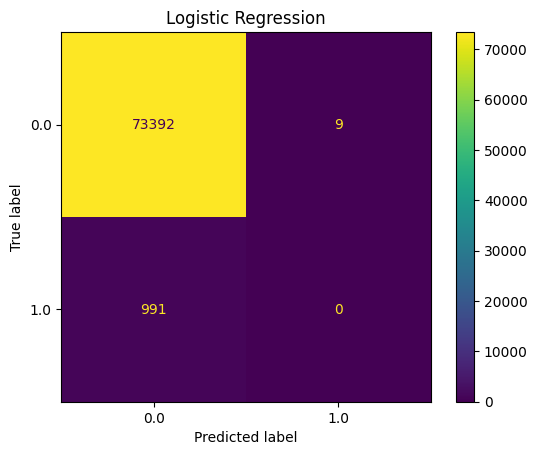

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression")
plt.show()

### Random Forest

In [28]:
def objective_rf(trial):
    if len(X_train) > OPTUNA_SAMPLE_SIZE:
        X_tune, _, y_tune, _ = train_test_split(
            X_train,
            y_train,
            train_size=OPTUNA_SAMPLE_SIZE,
            stratify=y_train,
            random_state=SEED,
        )
    else:
        X_tune = X_train
        y_tune = y_train

    X_fit, X_val, y_fit, y_val = train_test_split(
        X_tune,
        y_tune,
        test_size=OPTUNA_VALID_SIZE,
        stratify=y_tune,
        random_state=SEED,
    )

    class_weight = trial.suggest_categorical(
        "class_weight", [None, "balanced", "balanced_subsample"]
    )
    max_depth = trial.suggest_int("max_depth", 5, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=max_depth,
        min_samples_split=trial.suggest_int("min_samples_split", 2, 25),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 15),
        max_features=max_features,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=SEED,
    )

    rf.fit(X_fit, y_fit)
    y_score = rf.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, y_score)


study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_rf.optimize(objective_rf, n_trials=OPTUNA_N_TRIALS_RF, show_progress_bar=True)

rf = RandomForestClassifier(
    **study_rf.best_params,
    n_jobs=-1,
    random_state=SEED,
)

rf.fit(X_train, y_train)

study_rf.best_params

  0%|          | 0/15 [00:00<?, ?it/s]

{'class_weight': None,
 'max_depth': 10,
 'max_features': 'log2',
 'n_estimators': 200,
 'min_samples_split': 25,
 'min_samples_leaf': 11}

In [29]:
y_pred_rf = rf.predict(X_test)
y_score_rf = rf.predict_proba(X_test)[:, 1]

In [30]:
count_metrics(y_test, y_pred_rf, y_score_rf)

roc auc: 0.6413264261942171
average precision: 0.033784397960237834
balanced accuracy: 0.5
f1: 0.0


In [31]:
def objective_bagging(trial):
    if len(X_train) > OPTUNA_SAMPLE_SIZE:
        X_tune, _, y_tune, _ = train_test_split(
            X_train,
            y_train,
            train_size=OPTUNA_SAMPLE_SIZE,
            stratify=y_train,
            random_state=SEED,
        )
    else:
        X_tune = X_train
        y_tune = y_train

    X_fit, X_val, y_fit, y_val = train_test_split(
        X_tune,
        y_tune,
        test_size=OPTUNA_VALID_SIZE,
        stratify=y_tune,
        random_state=SEED,
    )

    base_tree = DecisionTreeClassifier(
        max_depth=trial.suggest_int("max_depth", 3, 25),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 50),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 30),
        max_features=trial.suggest_categorical("tree_max_features", ["sqrt", "log2", None]),
        class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
        random_state=SEED,
    )

    bagging = BaggingClassifier(
        estimator=base_tree,
        n_estimators=trial.suggest_int("n_estimators", 50, 300, step=50),
        max_samples=trial.suggest_float("max_samples", 0.5, 1.0),
        max_features=trial.suggest_float("bagging_max_features", 0.5, 1.0),
        bootstrap=True,
        bootstrap_features=False,
        n_jobs=-1,
        random_state=SEED,
    )

    bagging.fit(X_fit, y_fit)
    y_score = bagging.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, y_score)


study_bagging = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_bagging.optimize(
    objective_bagging,
    n_trials=OPTUNA_N_TRIALS_BAGGING,
    show_progress_bar=True,
)

best_bagging_params = study_bagging.best_params.copy()

base_tree = DecisionTreeClassifier(
    max_depth=best_bagging_params.pop("max_depth"),
    min_samples_split=best_bagging_params.pop("min_samples_split"),
    min_samples_leaf=best_bagging_params.pop("min_samples_leaf"),
    max_features=best_bagging_params.pop("tree_max_features"),
    class_weight=best_bagging_params.pop("class_weight"),
    random_state=SEED,
)

bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=best_bagging_params.pop("n_estimators"),
    max_samples=best_bagging_params.pop("max_samples"),
    max_features=best_bagging_params.pop("bagging_max_features"),
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
    random_state=SEED,
)

bagging.fit(X_train, y_train)

study_bagging.best_params

  0%|          | 0/15 [00:00<?, ?it/s]

{'max_depth': 19,
 'min_samples_split': 15,
 'min_samples_leaf': 28,
 'tree_max_features': 'log2',
 'class_weight': None,
 'n_estimators': 100,
 'max_samples': 0.687940757375273,
 'bagging_max_features': 0.6451759525471503}

In [32]:
y_pred_bagging = bagging.predict(X_test)
y_score_bagging = bagging.predict_proba(X_test)[:, 1]

In [33]:
count_metrics(y_test, y_pred_bagging, y_score_bagging)

roc auc: 0.6350109803506555
average precision: 0.03995959930634793
balanced accuracy: 0.5
f1: 0.0


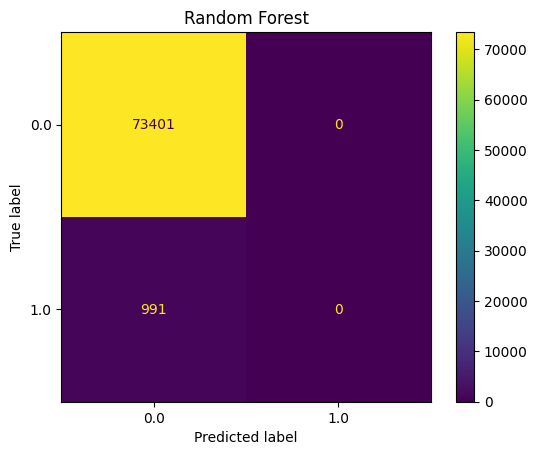

In [34]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest")
plt.show()

### Сравнение моделей

In [35]:
results_df = pd.DataFrame(
    [
        {
            "model": "always_zero",
            "roc_auc": roc_auc_score(y_test, y_pred_zeros),
            "average_precision": average_precision_score(y_test, y_pred_zeros),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_zeros),
            "f1": f1_score(y_test, y_pred_zeros),
        },
        {
            "model": "random_by_prior",
            "roc_auc": roc_auc_score(y_test, y_pred_random),
            "average_precision": average_precision_score(y_test, y_pred_random),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_random),
            "f1": f1_score(y_test, y_pred_random),
        },
        {
            "model": "logistic_regression",
            "roc_auc": roc_auc_score(y_test, y_score_lr),
            "average_precision": average_precision_score(y_test, y_score_lr),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_lr),
            "f1": f1_score(y_test, y_pred_lr),
        },
        {
            "model": "random_forest",
            "roc_auc": roc_auc_score(y_test, y_score_rf),
            "average_precision": average_precision_score(y_test, y_score_rf),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
            "f1": f1_score(y_test, y_pred_rf),
        },
        {
            "model": "bagging_trees",
            "roc_auc": roc_auc_score(y_test, y_score_bagging),
            "average_precision": average_precision_score(y_test, y_score_bagging),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_bagging),
            "f1": f1_score(y_test, y_pred_bagging),
        },
    ]
)

results_df = results_df.sort_values("average_precision", ascending=False).reset_index(
    drop=True
)
results_df.style.format(
    {
        "roc_auc": "{:.6f}",
        "average_precision": "{:.6f}",
        "balanced_accuracy": "{:.6f}",
        "f1": "{:.6f}",
    }
)

,model,roc_auc,average_precision,balanced_accuracy,f1
0,bagging_trees,0.635011,0.039960,0.500000,0.000000
1,random_forest,0.641326,0.033784,0.500000,0.000000
2,logistic_regression,0.625946,0.022551,0.499939,0.000000
3,random_by_prior,0.500238,0.013328,0.500238,0.013951
4,always_zero,0.500000,0.013321,0.500000,0.000000


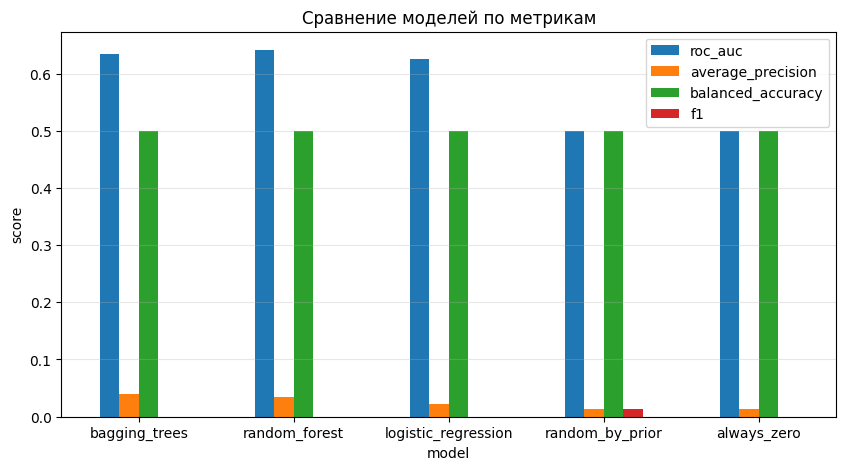

In [36]:
metrics_to_plot = ["roc_auc", "average_precision", "balanced_accuracy", "f1"]

results_df.set_index("model")[metrics_to_plot].plot(
    kind="bar", figsize=(10, 5), rot=0, title="Сравнение моделей по метрикам"
)

plt.ylabel("score")
plt.grid(axis="y", alpha=0.3)
plt.show()